# LKIPA Time Series Data Collection

In this notebook we develop the script to collect time series data from the LKIPA. 

- PUMP OFF
- PUMP ON (Sub-Threshold)
- PUMP ON (Threshold)
- PUMP ON (Super-Threshold)

PUMP OFF data is required to quantify the background noise level and frequency spectrum to subtract from the PUMP ON cases. 

----

*Post Attempt Remarks*: 
1. DC Bias and RF power have roughly linear relation for same $f_p$
2. So far maximum autocorrelation time ($\sim 3 \mu s$) observed for (df = 50kHz):
    - pump = 0.10 FS, DC Bias = 1.7 V   ( PSD peak $\sim 0.1$)
    - pump = 0.11 FS, DC Bias = 1.7 V   ( PSD peak $\sim 0.1$)
    - pump = 0.12 FS, DC Bias = 1.7 V   ( PSD peak $\sim 0.3$)
    - pump = 0.13 FS, DC Bias = 1.7 V   ( PSD peak $\sim 1$)
    - pump = 0.14 FS, DC Bias = 1.7 V   ( PSD peak $\sim 70$) !!
    - pump = 0.15 FS, DC Bias = 1.7 V   ( PSD peak $\sim 1000$) !!
    - pump = 0.16 FS, DC Bias = 1.7 V   ( PSD peak $\sim 1000$) !!
    - pump = 0.17 FS, DC Bias = 1.7 V   ( PSD peak $\sim 800$) !!
    - pump = 0.18 FS, DC Bias = 1.7 V   ( PSD peak $\sim 800$) !!
    - pump = 0.19 FS, DC Bias = 1.7 V   ( PSD peak $\sim 800$) !!
    - pump = 0.20 FS, DC Bias = 1.7 V   ( PSD peak $\sim 800$) !!
    - pump = 0.21 FS, DC Bias = 1.7 V   ( PSD peak $\sim 700$) !!
    - pump = 0.22 FS, DC Bias = 1.7 V   ( PSD peak $\sim 600$) !!
    - pump = 0.23 FS, DC Bias = 1.7 V   ( PSD peak $\sim 600$) !!
    - pump = 0.24 FS, DC Bias = 1.7 V   ( PSD peak $\sim 500$) !!
    - pump = 0.25 FS, DC Bias = 1.7 V   ( PSD peak $\sim 300$) !!
    - pump = 0.26 FS, DC Bias = 1.7 V   ( PSD peak $\sim 300$) !!
    - pump = 0.27 FS, DC Bias = 1.7 V   ( PSD peak $\sim 250$) !!
    - pump = 0.28 FS, DC Bias = 1.7 V   ( PSD peak $\sim 200$) !!

In [1]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm

from presto import test
from presto import lockin, utils
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample

## 1. PRESTO Configuration

In [2]:
# Network settings for Presto Hardware
ADDRESS = '130.237.35.90'       # IP Address
PORT    = 42873                 # TCP Port

# Input (ADC) settings
INPUT_PORT = 5                  # Correlated vacuum input to presto, output frm JPA
ADC_ATT = 0.0                   # dB, 0.0 to 27.0
INPUT_NCO = 0                   # Hz, 0 to 10 GHz
DF = 10e3                      # MHz

# FLUX PUMP Output (DAC) settings
FLUX_PORT = 2                   # Pump frequency comb output from presto, input to JPA
PUMP_AMP = 0.0                # amplitude of pump signal, 0 for vacuum
PHASEI = 0.0                    # rad
PHASEQ = PHASEI - np.pi / 2     # rad
f0= 4.428e9                     # Resonance Frequency (Hz)  4427780358
PUMP_NCO = 8.84e9               # NCO frequency for pump set to 8.4 GHz
PUMP_FREQ = 2 * f0 - PUMP_NCO   # Hz, 0 to 500 MHz, intermediate frequency

# DC BIAS settings
DC_PORT = 2                     # DC Bias for optimal operating point of JPA   
DAC_CURR = 32_000               # μA, 2250 to 40500   
DC_BIAS = 2.2                   # Set LKIPA Resonance to 4.428 GHz, taken from latest calibration (2.2 for PUMP OFF, 0.5 for PUMP= 0.25)

# Converter configuration for Presto hardware
CONVERTER_CONFIGURATION = {
    "adc_mode": AdcMode.Mixed,
    "adc_fsample": AdcFSample.G2,
    "dac_mode": DacMode.Mixed04,
    "dac_fsample": DacFSample.G8,
}     

# Number of pixels to be captured
N_PIX = 1_000             

## 2. Data Acquisition Loop

In [3]:
# Define data acquisition function
def data_acquisition(
    address: str,
    port: int,
    converter_configuration: dict,
    input_port: int,
    adc_att: float,
    input_nco: float,
    output_port: int,
    dac_curr: int,
    amp: float,
    freq: float,
    phasei: float,
    phaseq: float,
    output_nco: float,
    df: float,
    dcb_port: int,
    dcb_amp: float,
    n_pix: int
):
    with test.Test(address=address, port=port, **converter_configuration) as tst:
        # Get extra samples at the beginning and throw them away
        extra = 1000
        # Calculate number of samples from DF
        nr_samples = int(round(tst.get_fs("adc") / df))

        # Configure mixers for input and output ports
        tst.hardware.configure_mixer(input_nco, in_ports=input_port, sync=False)
        tst.hardware.configure_mixer(output_nco, out_ports=output_port, sync=True)

        # Configure ADC and DAC settings
        tst.hardware.set_adc_attenuation(input_port, adc_att)
        tst.hardware.set_dac_current(output_port, dac_curr)
        
        # Set DC bias for 4.2GHz operating point of JPA
        tst.hardware.set_dc_bias(port=dcb_port, bias=dcb_amp)
        tst.hardware.sleep(1e-4)

        # Configure output signal for pump tone
        tst.set_frequency(output_port, freq)
        tst.set_phase(output_port, phasei, phaseq)
        tst.set_scale(output_port, scale_i = amp, scale_q = amp)
        tst.hardware.sleep(1e-4)

        # Print hardware configuration statement
        print('Hardware configuration successful, initiating data acquisition ...')

        # Start data acquisition
        data_all = []
        with tqdm(total=n_pix, ncols=80) as pbar:
            for i in range(n_pix):
                tst.hardware.set_run(False)
                tst.set_dma_source(input_port)
                tst.start_dma(extra + nr_samples)
                tst.hardware.set_run(True)
                tst.wait_for_dma()
                tst.stop_dma()
                data = tst.get_dma_data(extra + nr_samples)
                tst.hardware.check_adc_intr_status()
                
                # Throw away initial `extra` data points, convert to FS
                if converter_configuration["adc_mode"] == AdcMode.Mixed:
                    data = data[2*extra:] / 32767

                elif converter_configuration["adc_mode"] == AdcMode.Direct:
                    data = data[extra:] / 32767

                # Append to data_all list
                data_all.append(data)
                
                # Update progress bar
                pbar.update(1)

        # set all outputs to 0
        tst.hardware.set_dc_bias(port=dcb_port, bias=0.0)
        tst.set_scale(output_port, scale_i = 0, scale_q = 0)
        
        # convert data list to np.array
        data_all = np.array(data_all)

        # Measurement metadata
        dt = tst.get_dt("adc")*1e9
        fs = tst.get_fs("adc")*1e-9

        # Print completion statement
        print('Data Acquisition Complete.')
    
    return data_all, dt, fs, nr_samples

In [4]:
data_all, dt, fs, n_samples = data_acquisition(
            address=ADDRESS,
            port=PORT,
            converter_configuration=CONVERTER_CONFIGURATION,
            input_port=INPUT_PORT,
            adc_att=ADC_ATT,
            input_nco=INPUT_NCO,
            output_port=FLUX_PORT,
            dac_curr=DAC_CURR,
            amp=PUMP_AMP,
            freq=PUMP_FREQ,
            phasei=PHASEI,
            phaseq=PHASEQ,
            output_nco=PUMP_NCO,
            df=DF,
            dcb_port=DC_PORT,
            dcb_amp=DC_BIAS,
            n_pix=N_PIX
        )

# Print measurement metadata
# ==========================

print('MEASUREMENT PARAMETERS:')
print('=======================')

# Analog-to-Digital Converter Mode
print(f'Mode: {CONVERTER_CONFIGURATION["adc_mode"]}')

# Number of pixels captured
print(f"Number of pixels: {N_PIX}")

# Pixel duration
print(f"Pixel time resolution (dt): {dt:.2f} ns")

# Sampling frequency of the ADC (GHz)
print(f"Sampling frequency (fs): {fs:.2f} GHz")

t_meas = 1e6 / DF # Measurement time per pixel (μs)
print(f"Total measurement time: {t_meas:.1f} µs")

# Frequency resolution (kHz)
print(f"Frequency resolution (DF): {DF/1e3:.1f} kHz")

# Data points captured per pixel
N_datastream = np.shape(data_all)[1]
print(f"Data points captured per pixel: {N_datastream}")

# Number of samples per pixel 
print(f"Number of samples per pixel: {n_samples}")

Hardware configuration successful, initiating data acquisition ...


100%|███████████████████████████████████████| 1000/1000 [00:34<00:00, 29.10it/s]


Data Acquisition Complete.
MEASUREMENT PARAMETERS:
Mode: AdcMode.Mixed
Number of pixels: 1000
Pixel time resolution (dt): 1.00 ns
Sampling frequency (fs): 1.00 GHz
Total measurement time: 100.0 µs
Frequency resolution (DF): 10.0 kHz
Data points captured per pixel: 200000
Number of samples per pixel: 100000


## 2.1 Extract time series data based on `AdcMode` 

In [5]:
if CONVERTER_CONFIGURATION["adc_mode"] == AdcMode.Mixed:
    print("Data format: Mixed mode (I and Q interleaved)")

    # Convert raw ADC data to full-scale (FS) units and separate I and Q components
    I_all = data_all[:, 0::2]
    Q_all = data_all[:, 1::2]
    print(f"Shape of I data: {I_all.shape}")

    # Assign data array for raw pixel I data
    for pix in range(N_PIX):
        I_all[pix]= I_all[pix] - np.mean(I_all[pix])  # remove DC component
    
elif CONVERTER_CONFIGURATION["adc_mode"] == AdcMode.Direct:
    print("Data format: Direct mode (I only)")

    # Convert raw ADC data to full-scale (FS) units
    I_all = data_all
    print(f"Shape of I data: {I_all.shape}")

    for pix in range(N_PIX):
        I_all[pix]= I_all[pix] #- np.mean(I_all[pix])  # remove DC component

Data format: Mixed mode (I and Q interleaved)
Shape of I data: (1000, 100000)


## 3. Time Series and FFT Plot

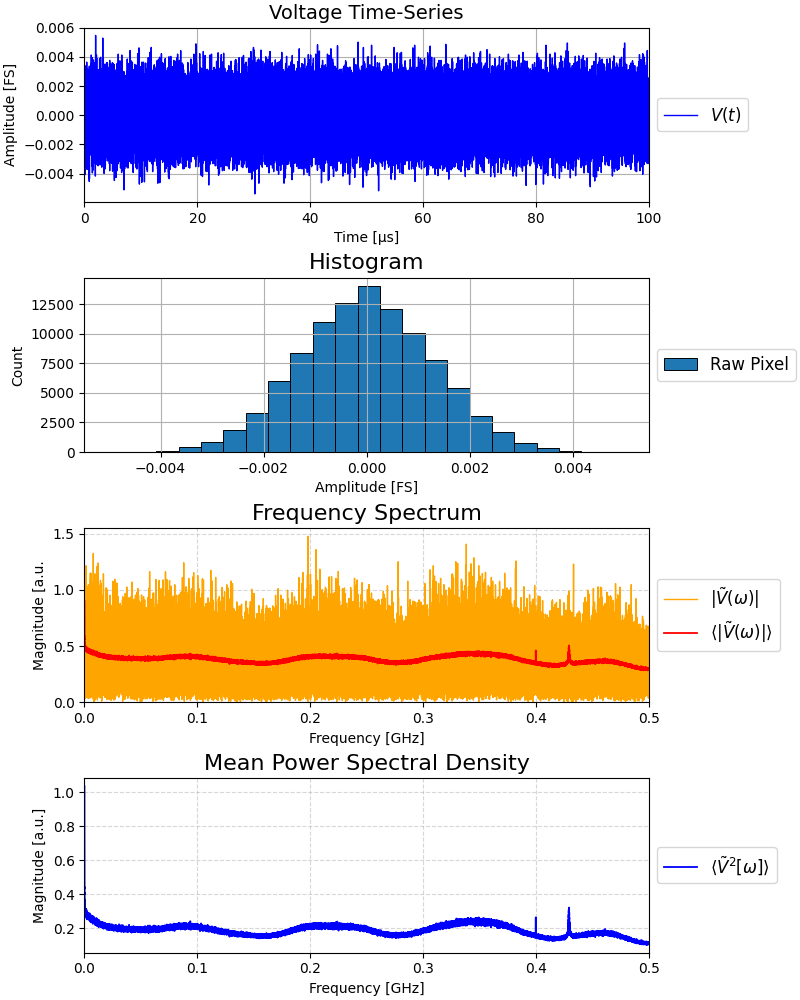

In [6]:
t_arr = dt * np.arange(0, n_samples, 1) * 1e-3    # μs, convert from ns seconds

# Example time series
raw = 0
data_raw = I_all[raw]

# FFT
# ===

# frequency array for FFT
f_arr = np.fft.rfftfreq(n_samples, dt)  # Hz

fft_data_list = [] #np.zeros((N_PIX, n_samples))
for pix in range(N_PIX):
    fft_data_list.append(np.fft.rfft(I_all[pix]))

# FFT of all time series
fft_data_list = np.array(fft_data_list)

# Example |FFT|
fft_raw = fft_data_list[raw]               # Real FFT of single pixel data

# Pixel Averaged |FFT|
fft_avg = np.mean(np.abs(fft_data_list), axis=0)    # FFT averaged over all pixels

# PSD 
# ===

# Mean PSD
PSD_avg = np.mean(np.abs(fft_data_list)  ** 2, axis = 0)   # PSD averaged over all pixels

# Save pump OFF averaged PSD for subtracting out background noise
_df = int(DF/1e3)
if PUMP_AMP== 0:
    np.savetxt(
        fname=f'Time series data/LKIPA-PSD-df={_df}khz-pixels={N_PIX}.txt',
        X= PSD_avg,
        delimiter=','
        )

# PLOT
# ====
fig, ax = plt.subplots(
    nrows=4,                    
    ncols=1,
    constrained_layout=True, 
    figsize=(8, 10)
    )

ax1, ax2, ax3, ax4 = ax

# Plot pixel averaged and single pixel data together in the first subplot
ax1.plot(t_arr, data_raw, label="$V(t)$", color='b', lw=1)
ax1.set_xlabel("Time [μs]")
ax1.set_ylabel("Amplitude [FS]")
ax1.set_title("Voltage Time-Series", fontsize=14)
ax1.set_xlim(0, t_meas)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax1.grid()

# Plot histogram of the data in the second subplot
ax2.hist(data_raw, bins=25, label="Raw Pixel", edgecolor='black', lw=0.7)
ax2.set_xlabel("Amplitude [FS]")
ax2.set_ylabel("Count")
ax2.set_title("Histogram", fontsize=16)
ax2.set_xlim(-np.max(np.abs(data_raw)), np.max(np.abs(data_raw)))
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax2.grid()

# Plot FFT
ax3.grid(alpha=0.5, linestyle='--')
ax3.plot(f_arr[1:-1], np.abs(fft_raw[1:-1]), label='$|\\tilde V(\\omega)|$', color='orange', lw=1)
ax3.plot(f_arr[1:-1], fft_avg[1:-1], label='$\\langle |\\tilde V(\\omega)| \\rangle$', color='red', lw=1.3)
ax3.set_xlabel("Frequency [GHz]")
ax3.set_ylabel("Magnitude [a.u.")
ax3.set_xlim(0, fs/2)
ax3.set_ylim(ymin=0)
ax3.set_title("Frequency Spectrum", fontsize=16)
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# Plot PSD
ax4.grid(alpha=0.5, linestyle='--')
ax4.plot(f_arr[1:-1], PSD_avg[1:-1], label="$\\langle \\tilde V^2[\\omega] \\rangle$", color = "b", lw=1.3)
ax4.set_xlabel("Frequency [GHz]")
ax4.set_ylabel("Magnitude [a.u.]")
ax4.set_xlim(0, fs/2)
ax4.set_title("Mean Power Spectral Density", fontsize=16)
ax4.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)


#fig.suptitle("Signal Analysis", fontsize=20)
plt.show()

## 3.1 Shift in Power Spectral Density

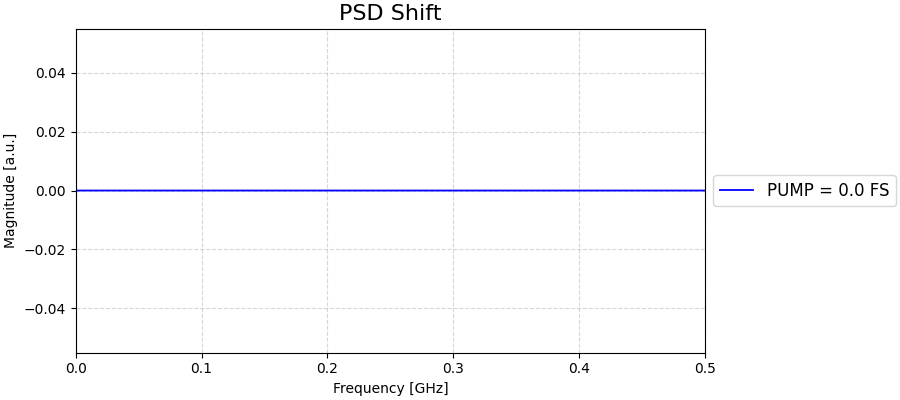

In [7]:
# Load PUMP OFF pixel averaged |FFT| into numpy array for comparison with PUMP ON cases

PSD_avg_PUMP_OFF = np.loadtxt(
    fname=f'Time series data/LKIPA-PSD-df={_df}khz-pixels={N_PIX}.txt',
    delimiter=','
)

fig31, ax31 = plt.subplots(figsize= (9, 4), constrained_layout = True)

PSD_Shift = PSD_avg - PSD_avg_PUMP_OFF

ax31.grid(alpha=0.5, linestyle='--')
ax31.plot(f_arr, PSD_Shift, label=f"PUMP = {PUMP_AMP} FS", color = "b", lw=1.3)

ax31.set_xlabel("Frequency [GHz]")
ax31.set_ylabel("Magnitude [a.u.]")
ax31.set_xlim(0, fs/2)
ax31.set_title("PSD Shift", fontsize=16)
ax31.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

## 4. 1-Time Autocorrelation


The 1-time auto-correlation function $\mathfrak{A}(\tau)$ for a discrete voltage time signal $I(t)$ over the time window $t \in [t_i, t_i + dt, \dots, t_f]$ is given by:

$$
\begin{aligned}
    \mathfrak{A}(\tau) &= \braket{ I(t) \cdot I(t - \tau) }_{t} \\
    &= \frac{1}{t_i - t_f}\sum^{t_f}_{t_i} I(t) \cdot I(t - \tau)
\end{aligned}
$$

Additionally, we can pixel average $\mathfrak{A}(\tau)$ to enhance the SNR.

In [8]:
frac = 20
autocorr_ts = np.zeros((N_PIX//frac, n_samples))

with tqdm(total=N_PIX//frac, ncols=80) as pbar:
    for pix in range(N_PIX//frac):
        autocorr_ts[pix] = np.correlate(
        a=I_all[pix], 
        v=I_all[pix],
        mode='same'
        )
        pbar.update(1)

autocorr_ts_avg = np.mean(autocorr_ts, axis=0)

100%|███████████████████████████████████████████| 50/50 [01:05<00:00,  1.30s/it]


## 4.1.1 Plot Autocorrelation

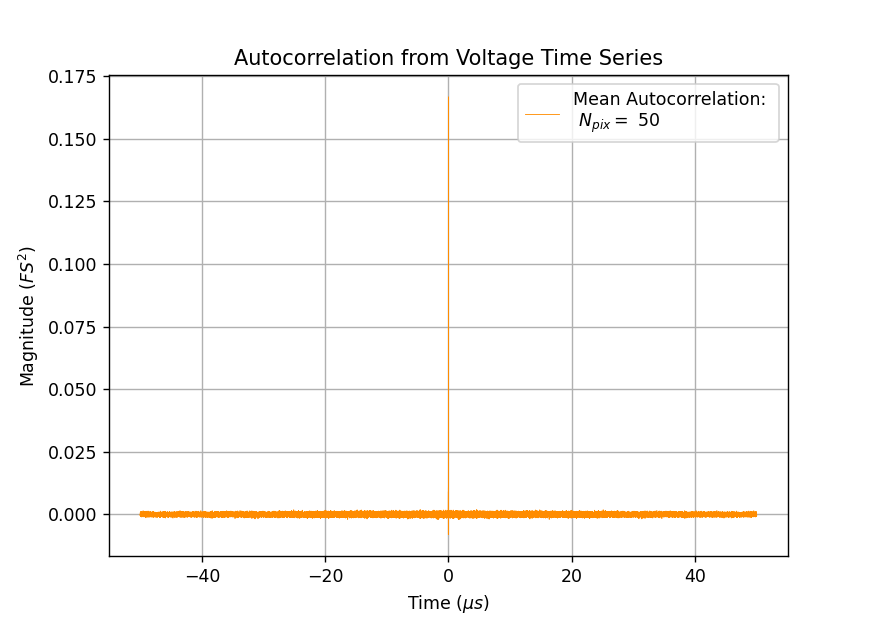

In [9]:
fig, ax= plt.subplots(
    figsize=(7, 5),
    dpi=125
)
ax.plot(
    t_arr - t_arr[-1]/2, 
    autocorr_ts[0],
    lw=0.5,
    color='darkorange',
    label='Mean Autocorrelation: \n $N_{pix} =$ ' + str(N_PIX // frac)
    )
ax.grid()
ax.legend(bbox_to_anchor=(1,1))
ax.set_xlabel('Time ($\\mu s$)')
ax.set_ylabel('Magnitude ($FS^2$)')
ax.set_title('Autocorrelation from Voltage Time Series')

# SAVE FIGURE
if PUMP_AMP!=0:
    fig.savefig(
        fname=f'Figures/Autocorrelation/LKIPA-Autocorr-DC_BIAS={DC_BIAS}V-pump={PUMP_AMP}-df={DF // 1e3}kHz.png'
    )

## 4.1.2 Comparison with Autocorrelation derived from Power Spectral Density

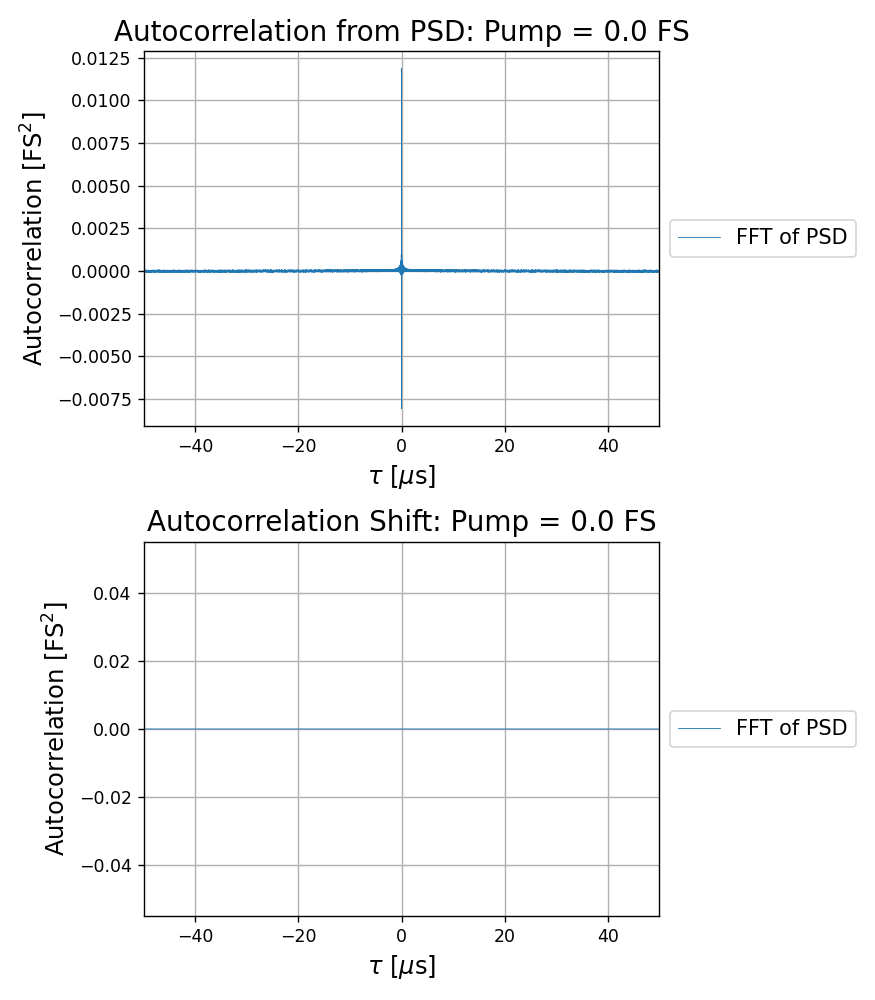

In [10]:

# Predicted autocorrelation from mean PSD
autocorr_predicted_PUMP_OFF = np.fft.irfft(PSD_avg_PUMP_OFF)[1:]
autocorr_predicted_PUMP_OFF = np.concatenate(
    (autocorr_predicted_PUMP_OFF[n_samples//2:], autocorr_predicted_PUMP_OFF[0:n_samples//2])
) 

autocorr_predicted = np.fft.irfft(PSD_avg)[1:]
autocorr_predicted = np.concatenate(
    (autocorr_predicted[n_samples//2:], autocorr_predicted[0:n_samples//2])
) 

fig, ax = plt.subplots(
    nrows=2,
    figsize=(7, 8), 
    tight_layout=True,
    dpi=125
    )

ax1, ax2 = ax

t_arr_symmetric=t_arr[1:] - t_arr[n_samples//2]


ax1.plot(
    t_arr_symmetric,
    (autocorr_predicted),
    label='FFT of PSD',
    lw=0.5
)
ax1.set_xlim(left=t_arr_symmetric[0], right=t_arr_symmetric[-1])

ax1.set_xlabel("$\\tau$ [$\\mu$s]", fontsize=14)
ax1.set_ylabel("Autocorrelation [FS$^2$]", fontsize=14)
ax1.set_title(f"Autocorrelation from PSD: Pump = {PUMP_AMP} FS", fontsize=16)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax1.grid()

ax2.plot(
    t_arr_symmetric,
    (autocorr_predicted - autocorr_predicted_PUMP_OFF),
    label='FFT of PSD',
    lw=0.5
)

ax2.set_xlim(left=t_arr_symmetric[0], right=t_arr_symmetric[-1])

ax2.set_xlabel("$\\tau$ [$\\mu$s]", fontsize=14)
ax2.set_ylabel("Autocorrelation [FS$^2$]", fontsize=14)
ax2.set_title(f"Autocorrelation Shift: Pump = {PUMP_AMP} FS", fontsize=16)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax2.grid()
plt.show()

# SAVE FIGURE
if PUMP_AMP!=0:
    fig.savefig(
        fname=f'Figures/Autocorrelation/LKIPA-Autocorr_Shift-DC_BIAS={DC_BIAS}V-pump={PUMP_AMP}-df={DF // 1e3}kHz.png'
    )

## 4.2 Removing the fast oscillations

Equivalent to shifting to the rotating frame.

/home/nanophys-meas/Desktop/Jai Master Thesis/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nanophys-meas/Desktop/Jai Master Thesis/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


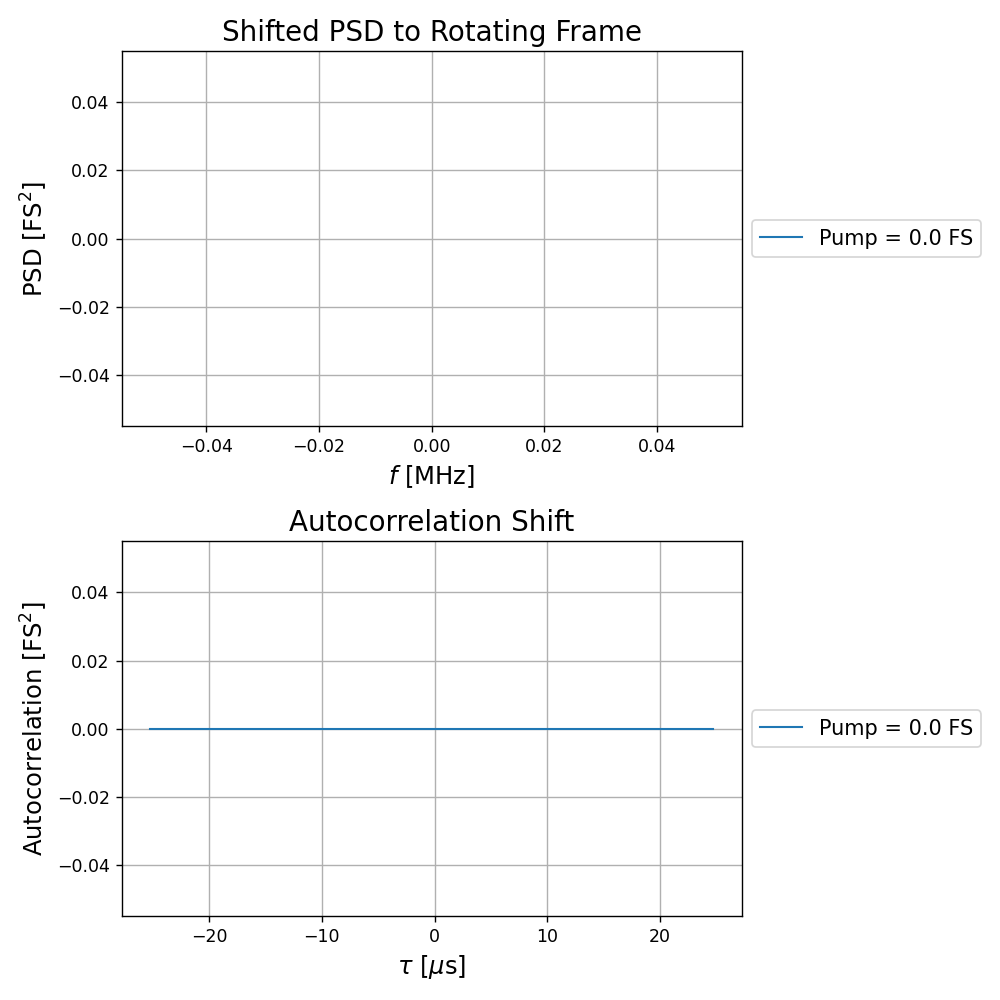

In [11]:
i0 = np.argmax(PSD_Shift[1:-1]) + 1
f0 = f_arr[i0]

# Bandwidth for FFT
bw = 200

f_arr_RW = 1e3 * (f_arr[i0 - bw: i0 + bw + 1] - f_arr[i0])

# PSD shift in rotating frame
PSD_Shift_RW = np.concatenate(
    (PSD_Shift[i0: i0 + bw + 1], PSD_Shift[i0 - bw: i0])
)

# Autocorrelation function : FFT of PSD
autocorr_predicted_RW = np.fft.ifft(PSD_Shift_RW)

# Number of samples
n_samples_RW = len(autocorr_predicted_RW)

# Time array
t_arr_RW = 1e6 * np.arange( - n_samples_RW // 2, n_samples_RW // 2, 1) /(DF * 2 * bw)

# Untwisted autocorrelation array
autocorr_predicted_RW = np.concatenate(
    (autocorr_predicted_RW[n_samples_RW//2:], autocorr_predicted_RW[0:n_samples_RW//2])
) 

# Save PSD and Autocorrelation function for given pump power
if PUMP_AMP !=0:
    np.savetxt(
        fname=f'Time series data/PSD_shift_rotating_frame-pump={PUMP_AMP}-df={DF//1e3}kHz',
        X=PSD_Shift_RW,
    )

    np.savetxt(
        fname=f'Time series data/autocorr_shift_rotating_frame-pump={PUMP_AMP}-df={DF//1e3}kHz',
        X=autocorr_predicted_RW
    )

# PLOT
# ====

fig, ax = plt.subplots(
    nrows=2,
    figsize=(8, 8), 
    tight_layout=True,
    dpi=125
    )
ax1, ax2 = ax

PSD_Shift_RW = PSD_Shift[i0 - bw: i0 + bw + 1]

ax1.plot(
    f_arr_RW, 
    PSD_Shift_RW,
    label=f'Pump = {PUMP_AMP} FS',
    lw=1.2
)

ax1.set_xlabel("$f$ [MHz]", fontsize=14)
ax1.set_ylabel("PSD [FS$^2$]", fontsize=14)
ax1.set_title(f"Shifted PSD to Rotating Frame", fontsize=16)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax1.grid()


ax2.plot(
    t_arr_RW, 
    autocorr_predicted_RW,
    label=f'Pump = {PUMP_AMP} FS',
    lw=1.2
)

ax2.set_xlabel("$\\tau$ [$\\mu$s]", fontsize=14)
ax2.set_ylabel("Autocorrelation [FS$^2$]", fontsize=14)
ax2.set_title(f"Autocorrelation Shift", fontsize=16)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax2.grid()
plt.show()

# SAVE FIGURE
if PUMP_AMP!=0:
    fig.savefig(
        fname=f'Figures/Autocorrelation/LKIPA-Autocorr_Shift_RW-DC_BIAS={DC_BIAS}V-pump={PUMP_AMP}-df={DF // 1e3}kHz.png'
    )